# Performance Benchmark: Python vs C++ Backends

This notebook compares the `pdist_tangency` computation across the Python and C++ backends and records per-call timings for `tangency()`.


In [1]:
import numpy as np
import timeit
import pandas as pd
import matplotlib.pyplot as plt

from ellphi.ellcloud import EllipseCloud
from ellphi.solver import pdist_tangency, tangency, has_cpp_backend
from ellphi.geometry import coef_from_cov
from ellphi._solver_python import quad_eval


In [2]:
def generate_ellipses(n_ellipses, seed=42, rng=None):
    if rng is None:
        sampler = np.random.RandomState(seed).random_sample
    else:
        sampler = rng.random
    means = sampler((n_ellipses, 2)) * 100
    covs_list = []
    for _ in range(n_ellipses):
        a = sampler() * 5 + 1
        b = sampler() * 5 + 1
        angle = sampler() * np.pi
        rot = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
        cov = rot @ np.diag([a, b]) @ rot.T
        covs_list.append(cov)
    covs = np.array(covs_list)
    coefs = coef_from_cov(means, covs)
    # Create dummy nbd and k, as they are not used in pdist_tangency
    dummy_nbd = np.array([[] for _ in range(n_ellipses)])
    return EllipseCloud(coef=coefs, mean=means, cov=covs, k=0, nbd=dummy_nbd)


In [3]:
ellipse_counts = [10, 50, 100, 150, 200]
cpp_available = has_cpp_backend()
if not cpp_available:
    print("C++ backend not available. Run 'python build_tangency_cpp.py' to build it before benchmarking.")

results = []

for n in ellipse_counts:
    print(f'Running benchmark for {n} ellipses...')
    ellipses = generate_ellipses(n)

    python_serial_time = timeit.timeit(
        lambda: pdist_tangency(ellipses, parallel=False, backend="python"),
        number=5,
    ) / 5

    python_parallel_time = timeit.timeit(
        lambda: pdist_tangency(
            ellipses, parallel=True, n_jobs=-1, backend="python"
        ),
        number=5,
    ) / 5

    row = {
        'n_ellipses': n,
        'python_serial_time': python_serial_time,
        'python_parallel_time': python_parallel_time,
    }

    if cpp_available:
        cpp_time = timeit.timeit(
            lambda: pdist_tangency(ellipses, parallel=False, backend="cpp"),
            number=5,
        ) / 5
        row['cpp_time'] = cpp_time
    else:
        row['cpp_time'] = np.nan

    results.append(row)

df_results = pd.DataFrame(results)
df_results


Running benchmark for 10 ellipses...
Running benchmark for 50 ellipses...
Running benchmark for 100 ellipses...
Running benchmark for 150 ellipses...
Running benchmark for 200 ellipses...


,n_ellipses,python_serial_time,python_parallel_time,cpp_time
0,10,0.003963,0.181964,0.000054
1,50,0.104983,0.071005,0.000519
2,100,0.418260,0.102071,0.002110
3,150,0.944627,0.162323,0.004714
4,200,1.694389,0.262242,0.008519


Running benchmark for 50 ellipses...


Running benchmark for 100 ellipses...


Running benchmark for 150 ellipses...


Running benchmark for 200 ellipses...


   n_ellipses  serial_time  parallel_time
0          10     0.015610       0.306349
1          50     0.442482       0.171189
2         100     1.745519       0.506291
3         150     3.922770       1.033764
4         200     6.865531       1.783256


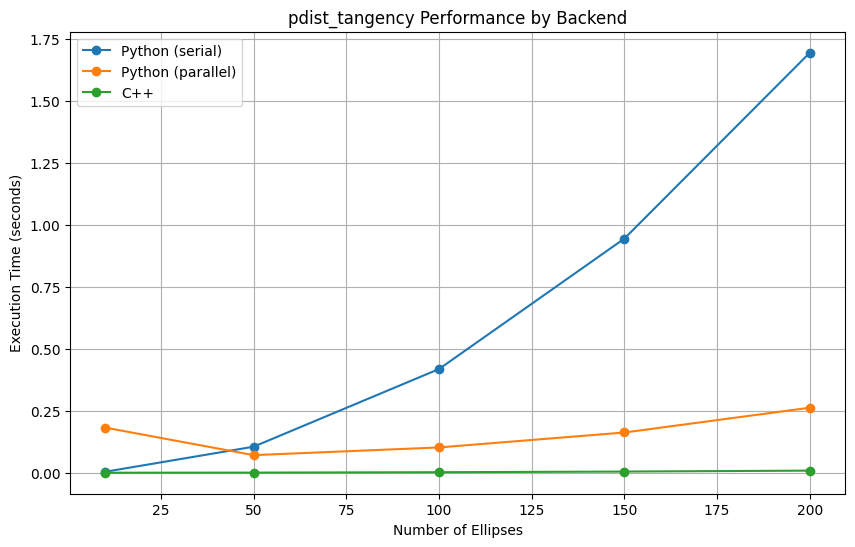

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(
    df_results['n_ellipses'],
    df_results['python_serial_time'],
    marker='o',
    label='Python (serial)',
)
plt.plot(
    df_results['n_ellipses'],
    df_results['python_parallel_time'],
    marker='o',
    label='Python (parallel)',
)
if cpp_available and df_results['cpp_time'].notna().any():
    plt.plot(
        df_results['n_ellipses'],
        df_results['cpp_time'],
        marker='o',
        label='C++',
    )
plt.title('pdist_tangency Performance by Backend')
plt.xlabel('Number of Ellipses')
plt.ylabel('Execution Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()


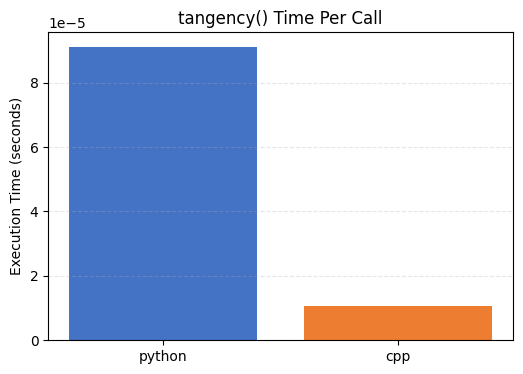

,backend,time_per_call
0,python,0.000091
1,cpp,0.000010


In [5]:
pair_cloud = generate_ellipses(2)
pcoef, qcoef = pair_cloud.coef[:2]

tangency_timings = [
    {
        'backend': 'python',
        'time_per_call': timeit.timeit(
            lambda: tangency(pcoef, qcoef, backend='python'),
            number=1000,
        ) / 1000,
    }
]

if cpp_available:
    tangency_timings.append(
        {
            'backend': 'cpp',
            'time_per_call': timeit.timeit(
                lambda: tangency(pcoef, qcoef, backend='cpp'),
                number=1000,
            ) / 1000,
        }
    )

tangency_df = pd.DataFrame(tangency_timings)
plt.figure(figsize=(6, 4))
plt.bar(
    tangency_df['backend'],
    tangency_df['time_per_call'],
    color=['#4472C4', '#ED7D31'][: len(tangency_df)],
)
plt.title('tangency() Time Per Call')
plt.ylabel('Execution Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()
tangency_df


## Error analysis / 誤差解析

To verify that the tangency results satisfy each ellipse polynomial, we repeat the computation several times and report the mean and median absolute and relative errors for both the Python and C++ backends. The analysis also monitors the difference between the polynomial evaluations of the two ellipses to ensure they coincide.


In [ ]:
error_trials = 1000
error_seed = 12345
error_rng = np.random.default_rng(error_seed)

tangency_inputs: list[tuple[np.ndarray, np.ndarray]] = []
for _ in range(error_trials):
    pair_cloud = generate_ellipses(2, rng=error_rng)
    tangency_inputs.append(tuple(coef.copy() for coef in pair_cloud.coef[:2]))


def compute_error_statistics(
    backend: str, inputs: list[tuple[np.ndarray, np.ndarray]]
) -> dict[str, float]:
    abs_errors: list[float] = []
    relative_errors: list[float] = []
    poly_differences: list[float] = []

    for pcoef, qcoef in inputs:
        result = tangency(pcoef, qcoef, backend=backend)
        expected = result.t ** 2
        denom = max(abs(expected), float(np.finfo(float).eps))

        eval_p = quad_eval(pcoef, result.point)
        eval_q = quad_eval(qcoef, result.point)
        poly_differences.append(abs(eval_p - eval_q))

        for value in (eval_p, eval_q):
            diff = value - expected
            abs_errors.append(abs(diff))
            relative_errors.append(abs(diff) / denom)

    return {
        "backend": backend,
        "trials": len(inputs),
        "abs_error_mean": float(np.mean(abs_errors)),
        "abs_error_median": float(np.median(abs_errors)),
        "relative_error_mean": float(np.mean(relative_errors)),
        "relative_error_median": float(np.median(relative_errors)),
        "poly_eval_difference_mean": float(np.mean(poly_differences)),
        "poly_eval_difference_median": float(np.median(poly_differences)),
    }


error_statistics = [compute_error_statistics("python", tangency_inputs)]
if cpp_available:
    error_statistics.append(compute_error_statistics("cpp", tangency_inputs))

error_summary_df = pd.DataFrame(error_statistics)
error_summary_df
